In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from google.colab import drive

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/UNGA/2026_02_06_ga_voting.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 947434
Columns: 20


In [4]:
print(df.columns.tolist())

['undl_id', 'ms_code', 'ms_name', 'ms_vote', 'date', 'session', 'resolution', 'draft', 'committee_report', 'meeting', 'title', 'agenda_title', 'subjects', 'vote_note', 'total_yes', 'total_no', 'total_abstentions', 'total_non_voting', 'total_ms', 'undl_link']


In [5]:
# Convert session to numeric
df["session"] = pd.to_numeric(df["session"], errors="coerce")

# Keep only Sessions 71–79 (2016–2025)
df_2016_2025 = df[df["session"].between(71, 79)].copy()

print("Original rows:", len(df))
print("Filtered rows:", len(df_2016_2025))

print("\nSessions included:")
print(sorted(df_2016_2025["session"].unique()))

Original rows: 947434
Filtered rows: 164629

Sessions included:
[np.float64(71.0), np.float64(72.0), np.float64(73.0), np.float64(74.0), np.float64(75.0), np.float64(76.0), np.float64(77.0), np.float64(78.0), np.float64(79.0)]


In [6]:
resolutions = (
    df_2016_2025[
        ["session", "resolution", "title", "subjects"]
    ]
    .drop_duplicates()
    .sort_values(["session", "resolution"])
)

print("Total unique resolutions:", len(resolutions))

display(resolutions.head(20))

Total unique resolutions: 853


,session,resolution,title,subjects
631729,71.0,A/RES/71/102,Information from Non-Self-Governing Territorie...,NON-SELF-GOVERNING TERRITORIES--REPORTS
771171,71.0,A/RES/71/103,Economic and other activities which affect the...,NON-SELF-GOVERNING TERRITORIES--ECONOMIC INTER...
770978,71.0,A/RES/71/104,Implementation of the Declaration of the Grant...,DECOLONIZATION--UN SYSTEM
583671,71.0,A/RES/71/11,Cooperation between the United Nations and the...,LEAGUE OF ARAB STATES--UN
771750,71.0,A/RES/71/121,Dissemination of information on decolonization...,DECOLONIZATION
632115,71.0,A/RES/71/122,Implementation of the Declaration on the Grant...,DECOLONIZATION
631150,71.0,A/RES/71/130,The Situation in the Syrian Arab Republic : re...,ARMED CONFLICTS PREVENTION
770399,71.0,A/RES/71/174,Report of the Human Rights Council : resolutio...,UN. HUMAN RIGHTS COUNCIL--REPORTS
801854,71.0,A/RES/71/179,"Combating glorification of Nazism, neo-Nazism ...",RACIAL DISCRIMINATION--ELIMINATION
801661,71.0,A/RES/71/181,A global call for concrete action for the tota...,RACIAL DISCRIMINATION--PROGRAMMES OF ACTION


In [7]:
# Convert text columns to uppercase and handle missing values
resolutions["title"] = resolutions["title"].fillna("").str.upper()
resolutions["subjects"] = resolutions["subjects"].fillna("").str.upper()

# -----------------------------
# Gaza / Palestine
# -----------------------------
gaza_keywords = [
    "PALESTIN",
    "GAZA",
    "ISRAEL",
    "OCCUPIED PALESTINIAN",
    "MIDDLE EAST"
]

gaza_resolutions = resolutions[
    resolutions["title"].str.contains("|".join(gaza_keywords), regex=True)
    |
    resolutions["subjects"].str.contains("|".join(gaza_keywords), regex=True)
]

# -----------------------------
# Ukraine
# -----------------------------
ukraine_keywords = [
    "UKRAINE",
    "AGGRESSION AGAINST UKRAINE",
    "TERRITORIAL INTEGRITY OF UKRAINE"
]

ukraine_resolutions = resolutions[
    resolutions["title"].str.contains("|".join(ukraine_keywords), regex=True)
    |
    resolutions["subjects"].str.contains("|".join(ukraine_keywords), regex=True)
]

# -----------------------------
# Climate
# -----------------------------
climate_keywords = [
    "CLIMATE",
    "SUSTAINABLE DEVELOPMENT",
    "ENVIRONMENT",
    "PARIS AGREEMENT",
    "UNFCCC",
    "GLOBAL WARMING"
]

climate_resolutions = resolutions[
    resolutions["title"].str.contains("|".join(climate_keywords), regex=True)
    |
    resolutions["subjects"].str.contains("|".join(climate_keywords), regex=True)
]

print("Gaza resolutions:", len(gaza_resolutions))
print("Ukraine resolutions:", len(ukraine_resolutions))
print("Climate resolutions:", len(climate_resolutions))

Gaza resolutions: 138
Ukraine resolutions: 14
Climate resolutions: 45


In [8]:
# Aggregate
aggregate_votes = df_2016_2025.copy()

# Gaza
gaza_votes = df_2016_2025[
    df_2016_2025["resolution"].isin(gaza_resolutions["resolution"])
].copy()

# Ukraine
ukraine_votes = df_2016_2025[
    df_2016_2025["resolution"].isin(ukraine_resolutions["resolution"])
].copy()

# Climate
climate_votes = df_2016_2025[
    df_2016_2025["resolution"].isin(climate_resolutions["resolution"])
].copy()

print("Aggregate vote records:", len(aggregate_votes))
print("Gaza vote records:", len(gaza_votes))
print("Ukraine vote records:", len(ukraine_votes))
print("Climate vote records:", len(climate_votes))

Aggregate vote records: 164629
Gaza vote records: 26634
Ukraine vote records: 2702
Climate vote records: 8685


In [9]:
def create_vote_matrix(df_votes):
    matrix = (
        df_votes
        .pivot_table(
            index="ms_name",
            columns="resolution",
            values="ms_vote",
            aggfunc="first"
        )
        .sort_index()
    )
    return matrix

aggregate_matrix = create_vote_matrix(aggregate_votes)
gaza_matrix = create_vote_matrix(gaza_votes)
ukraine_matrix = create_vote_matrix(ukraine_votes)
climate_matrix = create_vote_matrix(climate_votes)

print("Aggregate:", aggregate_matrix.shape)
print("Gaza:", gaza_matrix.shape)
print("Ukraine:", ukraine_matrix.shape)
print("Climate:", climate_matrix.shape)

Aggregate: (199, 853)
Gaza: (199, 138)
Ukraine: (199, 14)
Climate: (199, 45)


In [10]:
from itertools import combinations
import pandas as pd

def calculate_agreement(vote_matrix):
    countries = vote_matrix.index.tolist()
    records = []

    for c1, c2 in combinations(countries, 2):

        v1 = vote_matrix.loc[c1]
        v2 = vote_matrix.loc[c2]

        # Remove absent votes
        valid = (
            (v1 != "X") &
            (v2 != "X") &
            (~v1.isna()) &
            (~v2.isna())
        )

        if valid.sum() == 0:
            continue

        agreement = (v1[valid] == v2[valid]).mean()

        records.append({
            "country1": c1,
            "country2": c2,
            "agreement": agreement
        })

    return pd.DataFrame(records)

In [11]:
print(aggregate_matrix.isna().sum().sum())
print(gaza_matrix.isna().sum().sum())
print(ukraine_matrix.isna().sum().sum())
print(climate_matrix.isna().sum().sum())

5118
828
84
270


In [12]:
print(aggregate_votes["ms_vote"].unique())

['Y' 'X' 'A' 'N']


In [13]:
for name, matrix in [
    ("Aggregate", aggregate_matrix),
    ("Gaza", gaza_matrix),
    ("Ukraine", ukraine_matrix),
    ("Climate", climate_matrix),
]:
    print(name)
    print((matrix.notna() & (matrix != "X")).sum(axis=1).describe())
    print()

Aggregate
count    199.000000
mean     754.376884
std      150.921893
min       65.000000
25%      728.000000
50%      825.000000
75%      849.000000
max      853.000000
dtype: float64

Gaza
count    199.000000
mean     121.010050
std       29.313525
min        2.000000
25%      115.000000
50%      137.000000
75%      138.000000
max      138.000000
dtype: float64

Ukraine
count    199.000000
mean      11.572864
std        3.678146
min        0.000000
25%       10.000000
50%       14.000000
75%       14.000000
max       14.000000
dtype: float64

Climate
count    199.000000
mean      39.603015
std        8.731008
min        4.000000
25%       39.000000
50%       43.000000
75%       45.000000
max       45.000000
dtype: float64



In [14]:
print(aggregate_matrix.shape)
print(gaza_matrix.shape)
print(ukraine_matrix.shape)
print(climate_matrix.shape)

(199, 853)
(199, 138)
(199, 14)
(199, 45)


In [15]:
import pandas as pd
from itertools import combinations

def compute_agreement(voting_matrix):

    countries = voting_matrix.index
    agreements = []

    for c1, c2 in combinations(countries, 2):

        v1 = voting_matrix.loc[c1]
        v2 = voting_matrix.loc[c2]

        mask = (
            v1.notna() &
            v2.notna() &
            (v1 != "X") &
            (v2 != "X")
        )

        if mask.sum() > 0:

            agreement = (v1[mask] == v2[mask]).mean()

            agreements.append({
                "country1": c1,
                "country2": c2,
                "agreement": agreement
            })

    return pd.DataFrame(agreements)

In [16]:
aggregate_agreement = compute_agreement(aggregate_matrix)
gaza_agreement = compute_agreement(gaza_matrix)
ukraine_agreement = compute_agreement(ukraine_matrix)
climate_agreement = compute_agreement(climate_matrix)

print(len(aggregate_agreement))
print(len(gaza_agreement))
print(len(ukraine_agreement))
print(len(climate_agreement))

19675
19670
18811
19670


In [17]:
all_countries = sorted(df_2016_2025["ms_name"].unique())

In [18]:
def create_graph(df, all_countries, threshold=0.80):

    G = nx.Graph()

    G.add_nodes_from(all_countries)

    for _, row in df.iterrows():

        if row["agreement"] >= threshold:

            G.add_edge(
                row["country1"],
                row["country2"],
                weight=row["agreement"]
            )

    return G

In [19]:
aggregate_G = create_graph(aggregate_agreement, all_countries)
gaza_G = create_graph(gaza_agreement, all_countries)
ukraine_G = create_graph(ukraine_agreement, all_countries)
climate_G = create_graph(climate_agreement, all_countries)

In [20]:
all_countries = sorted(df_2016_2025["ms_name"].unique())

print(len(all_countries))

199


In [21]:
import community.community_louvain as community_louvain

partition_aggregate = community_louvain.best_partition(aggregate_G)
partition_gaza = community_louvain.best_partition(gaza_G)
partition_ukraine = community_louvain.best_partition(ukraine_G)
partition_climate = community_louvain.best_partition(climate_G)

In [22]:
for country in ["United States","China","Russian Federation","United Kingdom","France","India","Germany","Japan","Brazil","Pakistan","South Africa","Indonesia","Saudi Arabia","Iran","Egypt","Nigeria","Mexico","Argentina","Canada","Australia","Italy","Republic of Korea","Türkiye","Ukraine","Israel"]:
    print(country, "Aggregate:", partition_aggregate.get(country), "Gaza:", partition_gaza.get(country), "Ukraine:", partition_ukraine.get(country), "Climate:", partition_climate.get(country))

United States Aggregate: None Gaza: None Ukraine: None Climate: None
China Aggregate: None Gaza: None Ukraine: None Climate: None
Russian Federation Aggregate: None Gaza: None Ukraine: None Climate: None
United Kingdom Aggregate: None Gaza: None Ukraine: None Climate: None
France Aggregate: None Gaza: None Ukraine: None Climate: None
India Aggregate: None Gaza: None Ukraine: None Climate: None
Germany Aggregate: None Gaza: None Ukraine: None Climate: None
Japan Aggregate: None Gaza: None Ukraine: None Climate: None
Brazil Aggregate: None Gaza: None Ukraine: None Climate: None
Pakistan Aggregate: None Gaza: None Ukraine: None Climate: None
South Africa Aggregate: None Gaza: None Ukraine: None Climate: None
Indonesia Aggregate: None Gaza: None Ukraine: None Climate: None
Saudi Arabia Aggregate: None Gaza: None Ukraine: None Climate: None
Iran Aggregate: None Gaza: None Ukraine: None Climate: None
Egypt Aggregate: None Gaza: None Ukraine: None Climate: None
Nigeria Aggregate: None Gaza: N

In [23]:
print(list(partition_aggregate.keys())[:50])

['AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'ANDORRA', 'ANGOLA', 'ANTIGUA AND BARBUDA', 'ARGENTINA', 'ARMENIA', 'AUSTRALIA', 'AUSTRIA', 'AZERBAIJAN', 'BAHAMAS', 'BAHRAIN', 'BANGLADESH', 'BARBADOS', 'BELARUS', 'BELGIUM', 'BELIZE', 'BENIN', 'BHUTAN', 'BOLIVIA (PLURINATIONAL STATE OF)', 'BOSNIA AND HERZEGOVINA', 'BOTSWANA', 'BRAZIL', 'BRUNEI DARUSSALAM', 'BULGARIA', 'BURKINA FASO', 'BURUNDI', 'CABO VERDE', 'CAMBODIA', 'CAMEROON', 'CANADA', 'CENTRAL AFRICAN REPUBLIC', 'CHAD', 'CHILE', 'CHINA', 'COLOMBIA', 'COMOROS', 'CONGO', 'COSTA RICA', "COTE D'IVOIRE", 'CROATIA', 'CUBA', 'CYPRUS', 'CZECHIA', "CÔTE D'IVOIRE", "DEMOCRATIC PEOPLE'S REPUBLIC OF KOREA", 'DEMOCRATIC REPUBLIC OF THE CONGO', 'DENMARK', 'DJIBOUTI']


In [24]:
print("UNITED STATES" in partition_aggregate)
print("CHINA" in partition_aggregate)
print("INDIA" in partition_aggregate)
print("RUSSIAN FEDERATION" in partition_aggregate)

True
True
True
True


In [25]:
print(len(partition_aggregate))
print(len(partition_gaza))
print(len(partition_ukraine))
print(len(partition_climate))

199
199
199
199


In [26]:
print(len(partition_aggregate))
print(list(partition_aggregate.keys())[:20])
print("UNITED STATES" in partition_aggregate)

199
['AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'ANDORRA', 'ANGOLA', 'ANTIGUA AND BARBUDA', 'ARGENTINA', 'ARMENIA', 'AUSTRALIA', 'AUSTRIA', 'AZERBAIJAN', 'BAHAMAS', 'BAHRAIN', 'BANGLADESH', 'BARBADOS', 'BELARUS', 'BELGIUM', 'BELIZE', 'BENIN', 'BHUTAN']
True


In [27]:
for country in [
    "UNITED STATES",
    "CHINA",
    "RUSSIAN FEDERATION",
    "UNITED KINGDOM",
    "FRANCE",
    "INDIA",
    "GERMANY",
    "JAPAN",
    "BRAZIL",
    "PAKISTAN",
    "SOUTH AFRICA",
    "INDONESIA",
    "SAUDI ARABIA",
    "IRAN (ISLAMIC REPUBLIC OF)",
    "EGYPT",
    "NIGERIA",
    "MEXICO",
    "ARGENTINA",
    "CANADA",
    "AUSTRALIA",
    "ITALY",
    "REPUBLIC OF KOREA",
    "TÜRKIYE",
    "UKRAINE",
    "ISRAEL"
]:

    print(
        country,
        "Aggregate:", partition_aggregate.get(country),
        "Gaza:", partition_gaza.get(country),
        "Ukraine:", partition_ukraine.get(country),
        "Climate:", partition_climate.get(country)
    )

UNITED STATES Aggregate: 4 Gaza: 5 Ukraine: 1 Climate: 3
CHINA Aggregate: 2 Gaza: 0 Ukraine: 5 Climate: 2
RUSSIAN FEDERATION Aggregate: 3 Gaza: 1 Ukraine: 5 Climate: 2
UNITED KINGDOM Aggregate: 1 Gaza: 1 Ukraine: 1 Climate: 4
FRANCE Aggregate: 1 Gaza: 1 Ukraine: 1 Climate: 4
INDIA Aggregate: 2 Gaza: 0 Ukraine: 5 Climate: 2
GERMANY Aggregate: 1 Gaza: 1 Ukraine: 1 Climate: 4
JAPAN Aggregate: 1 Gaza: 1 Ukraine: 1 Climate: 4
BRAZIL Aggregate: 2 Gaza: 3 Ukraine: 6 Climate: 2
PAKISTAN Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
SOUTH AFRICA Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
INDONESIA Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
SAUDI ARABIA Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
IRAN (ISLAMIC REPUBLIC OF) Aggregate: 2 Gaza: 0 Ukraine: 5 Climate: 0
EGYPT Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
NIGERIA Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 2
MEXICO Aggregate: 2 Gaza: 1 Ukraine: 6 Climate: 2
ARGENTINA Aggregate: 2 Gaza: 0 Ukraine: 2 Climate: 2
CANADA Aggregate: 1 Gaza: 5 Ukraine

In [28]:
print("TURKEY" in partition_aggregate)

True


In [29]:
for country in [
    "UNITED STATES",
    "CHINA",
    "RUSSIAN FEDERATION",
    "UNITED KINGDOM",
    "FRANCE",
    "INDIA",
    "GERMANY",
    "JAPAN",
    "BRAZIL",
    "PAKISTAN",
    "SOUTH AFRICA",
    "INDONESIA",
    "SAUDI ARABIA",
    "IRAN (ISLAMIC REPUBLIC OF)",
    "EGYPT",
    "NIGERIA",
    "MEXICO",
    "ARGENTINA",
    "CANADA",
    "AUSTRALIA",
    "ITALY",
    "REPUBLIC OF KOREA",
    "TURKEY",
    "UKRAINE",
    "ISRAEL"
]:

    print(
        country,
        "Aggregate:", partition_aggregate.get(country),
        "Gaza:", partition_gaza.get(country),
        "Ukraine:", partition_ukraine.get(country),
        "Climate:", partition_climate.get(country)
    )

UNITED STATES Aggregate: 4 Gaza: 5 Ukraine: 1 Climate: 3
CHINA Aggregate: 2 Gaza: 0 Ukraine: 5 Climate: 2
RUSSIAN FEDERATION Aggregate: 3 Gaza: 1 Ukraine: 5 Climate: 2
UNITED KINGDOM Aggregate: 1 Gaza: 1 Ukraine: 1 Climate: 4
FRANCE Aggregate: 1 Gaza: 1 Ukraine: 1 Climate: 4
INDIA Aggregate: 2 Gaza: 0 Ukraine: 5 Climate: 2
GERMANY Aggregate: 1 Gaza: 1 Ukraine: 1 Climate: 4
JAPAN Aggregate: 1 Gaza: 1 Ukraine: 1 Climate: 4
BRAZIL Aggregate: 2 Gaza: 3 Ukraine: 6 Climate: 2
PAKISTAN Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
SOUTH AFRICA Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
INDONESIA Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
SAUDI ARABIA Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
IRAN (ISLAMIC REPUBLIC OF) Aggregate: 2 Gaza: 0 Ukraine: 5 Climate: 0
EGYPT Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 0
NIGERIA Aggregate: 2 Gaza: 0 Ukraine: 6 Climate: 2
MEXICO Aggregate: 2 Gaza: 1 Ukraine: 6 Climate: 2
ARGENTINA Aggregate: 2 Gaza: 0 Ukraine: 2 Climate: 2
CANADA Aggregate: 1 Gaza: 5 Ukraine

In [30]:
from collections import Counter
print("Aggregate:", Counter(partition_aggregate.values()))
print("Climate:", Counter(partition_climate.values()))

Aggregate: Counter({2: 139, 1: 56, 4: 2, 0: 1, 3: 1})
Climate: Counter({2: 102, 4: 51, 0: 38, 3: 7, 1: 1})


In [31]:
df_2016_2025["ms_vote"].value_counts()

,count
ms_vote,
Y,121364
A,17464
X,14508
N,11293


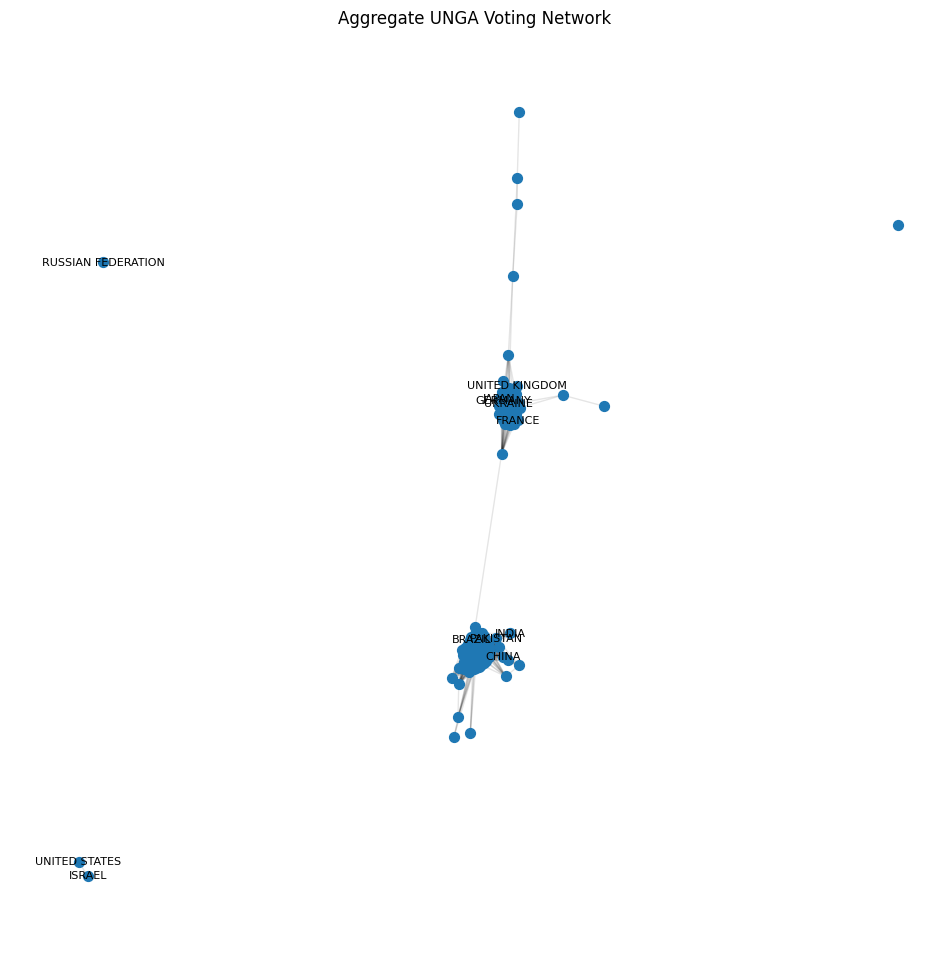

In [32]:
import networkx as nx
import matplotlib.pyplot as plt

major = [
    "UNITED STATES",
    "CHINA",
    "RUSSIAN FEDERATION",
    "INDIA",
    "UNITED KINGDOM",
    "FRANCE",
    "GERMANY",
    "BRAZIL",
    "JAPAN",
    "ISRAEL",
    "UKRAINE",
    "PAKISTAN"
]

pos = nx.spring_layout(aggregate_G, seed=42)

plt.figure(figsize=(12,12))

nx.draw_networkx_nodes(
    aggregate_G,
    pos,
    node_size=50
)

nx.draw_networkx_edges(
    aggregate_G,
    pos,
    alpha=0.1
)

labels = {
    n:n for n in aggregate_G.nodes()
    if n in major
}

nx.draw_networkx_labels(
    aggregate_G,
    pos,
    labels=labels,
    font_size=8
)

plt.axis("off")
plt.title("Aggregate UNGA Voting Network")
plt.show()

In [33]:
pos = nx.spring_layout(
    aggregate_G,
    k=1.5,
    iterations=500,
    seed=42
)

In [34]:
major = [
    "UNITED STATES",
    "CHINA",
    "RUSSIAN FEDERATION",
    "UNITED KINGDOM",
    "GERMANY",
    "INDIA",
    "JAPAN",
    "BRAZIL",
    "ISRAEL"
]

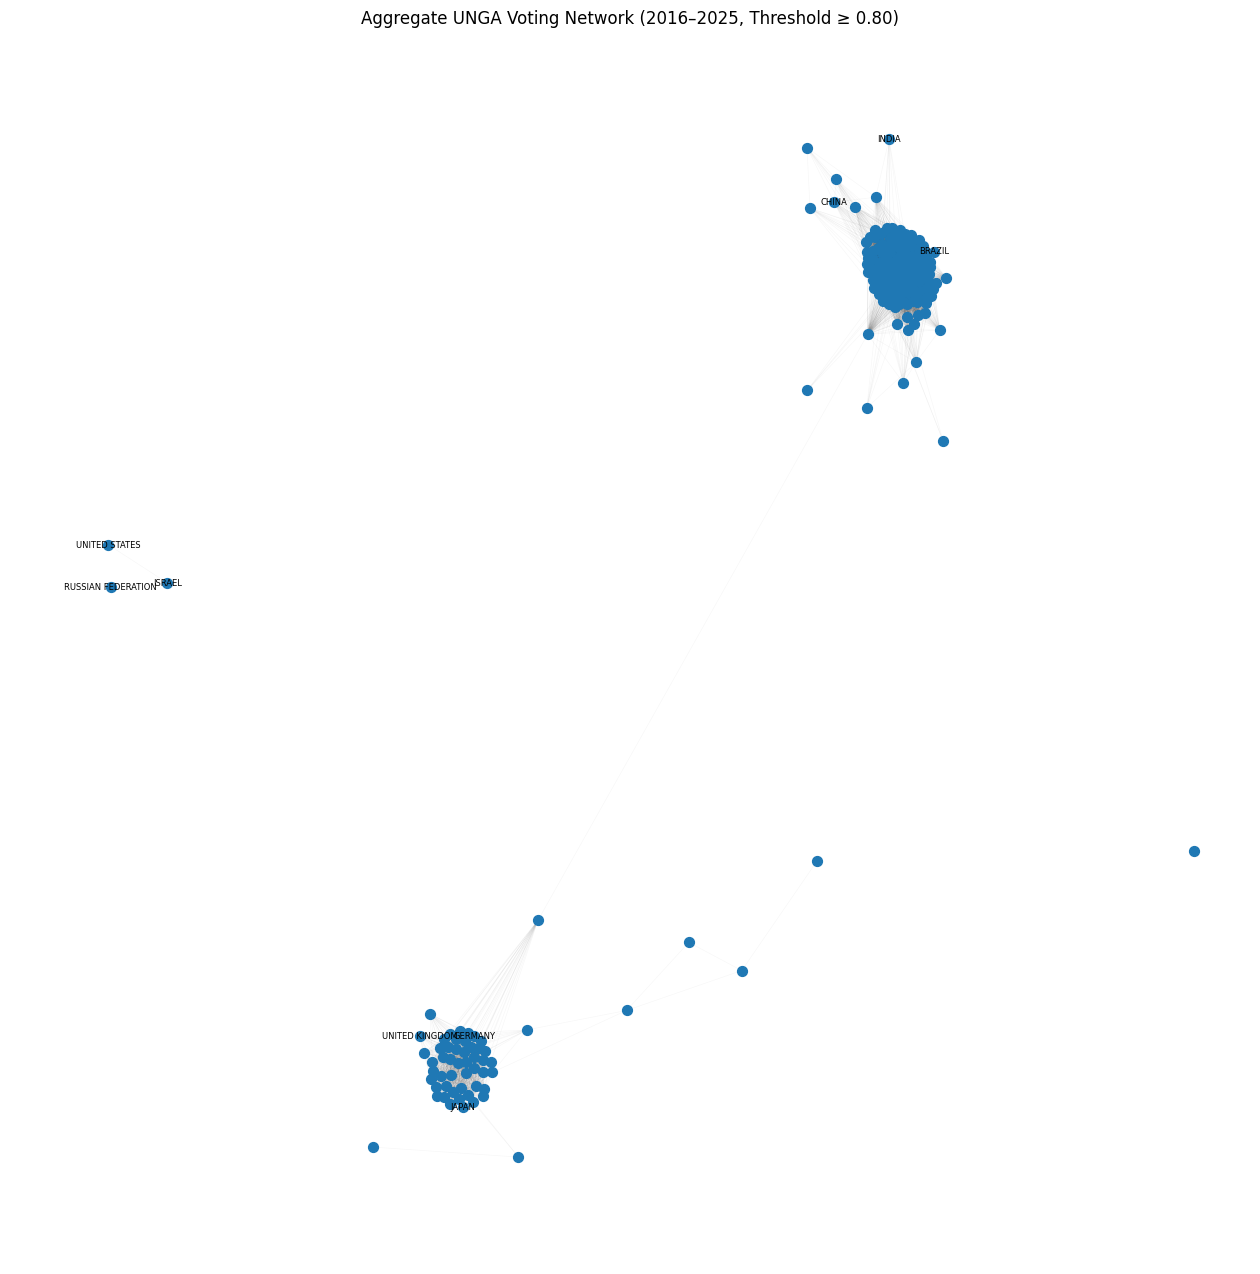

In [35]:
major = [
    "UNITED STATES",
    "CHINA",
    "RUSSIAN FEDERATION",
    "UNITED KINGDOM",
    "GERMANY",
    "INDIA",
    "JAPAN",
    "BRAZIL",
    "ISRAEL"
]

pos = nx.spring_layout(
    aggregate_G,
    k=1.5,
    iterations=500,
    seed=42
)

plt.figure(figsize=(16,16))

nx.draw_networkx_nodes(
    aggregate_G,
    pos,
    node_size=50
)

nx.draw_networkx_edges(
    aggregate_G,
    pos,
    alpha=0.03,
    width=0.5
)

labels = {
    n: n for n in aggregate_G.nodes()
    if n in major
}

nx.draw_networkx_labels(
    aggregate_G,
    pos,
    labels=labels,
    font_size=6
)

plt.title(
    "Aggregate UNGA Voting Network (2016–2025, Threshold ≥ 0.80)"
)

plt.axis("off")
plt.show()

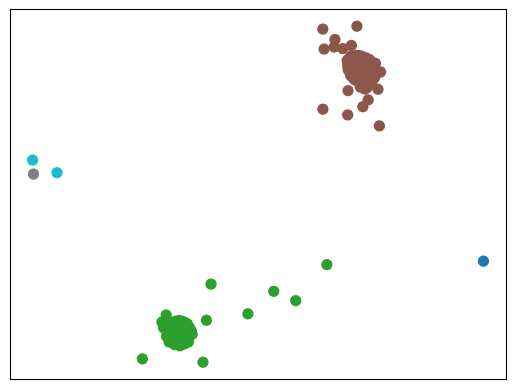

In [36]:
node_colors = [
    partition_aggregate[node]
    for node in aggregate_G.nodes()
]

nx.draw_networkx_nodes(
    aggregate_G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=50
)

In [37]:
[
    "UNITED STATES",
    "RUSSIAN FEDERATION",
    "CHINA",
    "UNITED KINGDOM",
    "ISRAEL"
]

['UNITED STATES', 'RUSSIAN FEDERATION', 'CHINA', 'UNITED KINGDOM', 'ISRAEL']

In [38]:
sizes = []

for node in aggregate_G.nodes():
    if node in major:
        sizes.append(400)
    else:
        sizes.append(50)

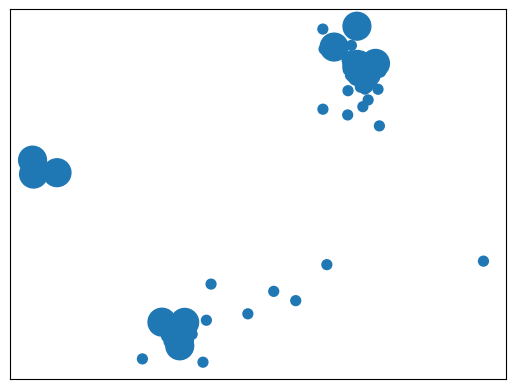

In [39]:
nx.draw_networkx_nodes(
    aggregate_G,
    pos,
    node_size=sizes
)

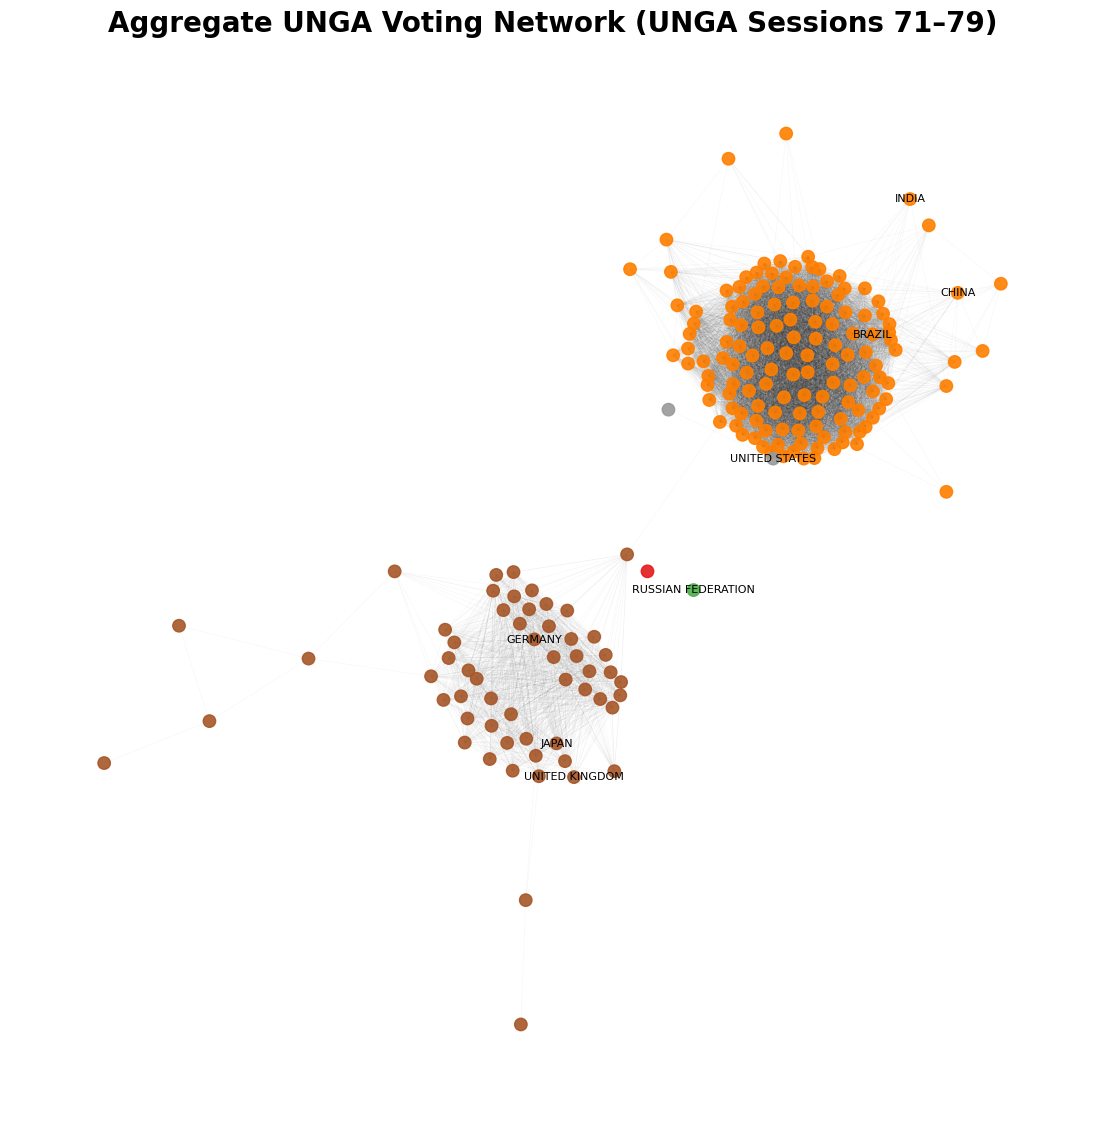

In [40]:
import matplotlib.pyplot as plt
import networkx as nx
from community import community_louvain

# Detect communities
partition = community_louvain.best_partition(
    aggregate_G,
    random_state=42
)

# Generate layout
pos = nx.kamada_kawai_layout(aggregate_G)

# Community colors
colors = [partition[node] for node in aggregate_G.nodes()]

plt.figure(figsize=(14,14))

# Draw nodes
nx.draw_networkx_nodes(
    aggregate_G,
    pos,
    node_color=colors,
    cmap=plt.cm.Set1,
    node_size=80,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(
    aggregate_G,
    pos,
    alpha=0.03,
    width=0.5
)

# Add ONLY important labels
labels = {
    "UNITED STATES":"UNITED STATES",
    "RUSSIAN FEDERATION":"RUSSIAN FEDERATION",
    "CHINA":"CHINA",
    "UNITED KINGDOM":"UNITED KINGDOM",
    "BRAZIL":"BRAZIL",
    "GERMANY":"GERMANY",
    "INDIA":"INDIA",
    "JAPAN":"JAPAN"
}

nx.draw_networkx_labels(
    aggregate_G,
    pos,
    labels=labels,
    font_size=8
)

plt.title(
    "Aggregate UNGA Voting Network (UNGA Sessions 71–79)",
    fontsize=20,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    "Figure_8_1_Aggregate_Network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

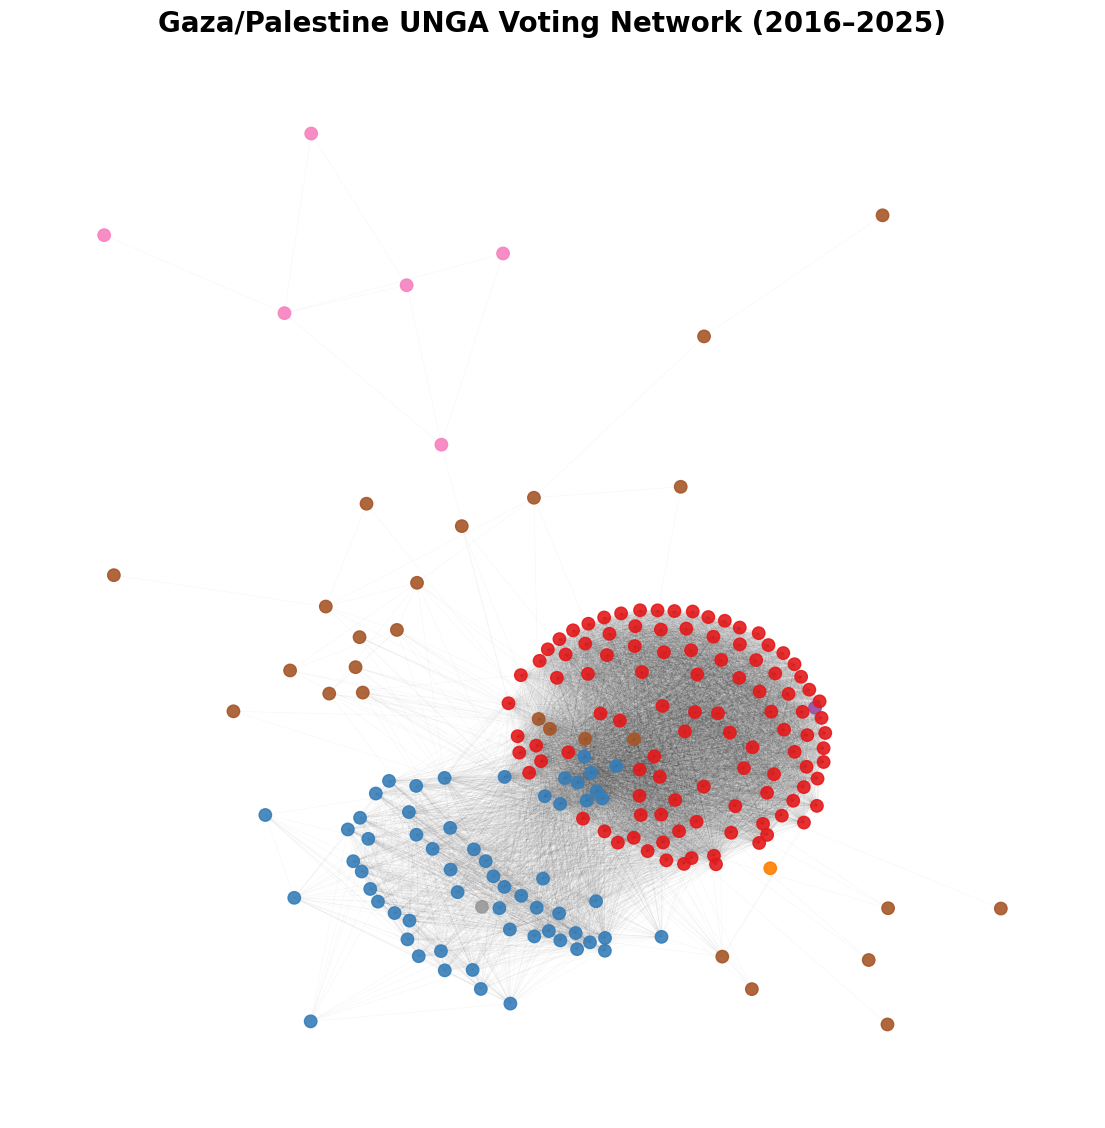

In [41]:
import matplotlib.pyplot as plt
import networkx as nx
from community import community_louvain

# Detect communities
partition = community_louvain.best_partition(
    gaza_G,
    random_state=42
)

# Generate layout
pos = nx.kamada_kawai_layout(gaza_G)

# Community colors
colors = [partition[node] for node in gaza_G.nodes()]

plt.figure(figsize=(14,14))

# Draw nodes
nx.draw_networkx_nodes(
    gaza_G,
    pos,
    node_color=colors,
    cmap=plt.cm.Set1,
    node_size=80,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(
    gaza_G,
    pos,
    alpha=0.03,
    width=0.5
)

# IMPORTANT COUNTRIES
labels = {
    "UNITED STATES":"UNITED STATES",
    "ISRAEL":"ISRAEL",
    "CHINA":"CHINA",
    "SAUDI ARABIA":"SAUDI ARABIA",
    "PAKISTAN":"PAKISTAN",
    "EGYPT":"EGYPT"
}

# Uncomment if you want labels
# nx.draw_networkx_labels(
#     gaza_G,
#     pos,
#     labels=labels,
#     font_size=8
# )

plt.title(
    "Gaza/Palestine UNGA Voting Network (2016–2025)",
    fontsize=20,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    "Figure_8_2_Gaza_Network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

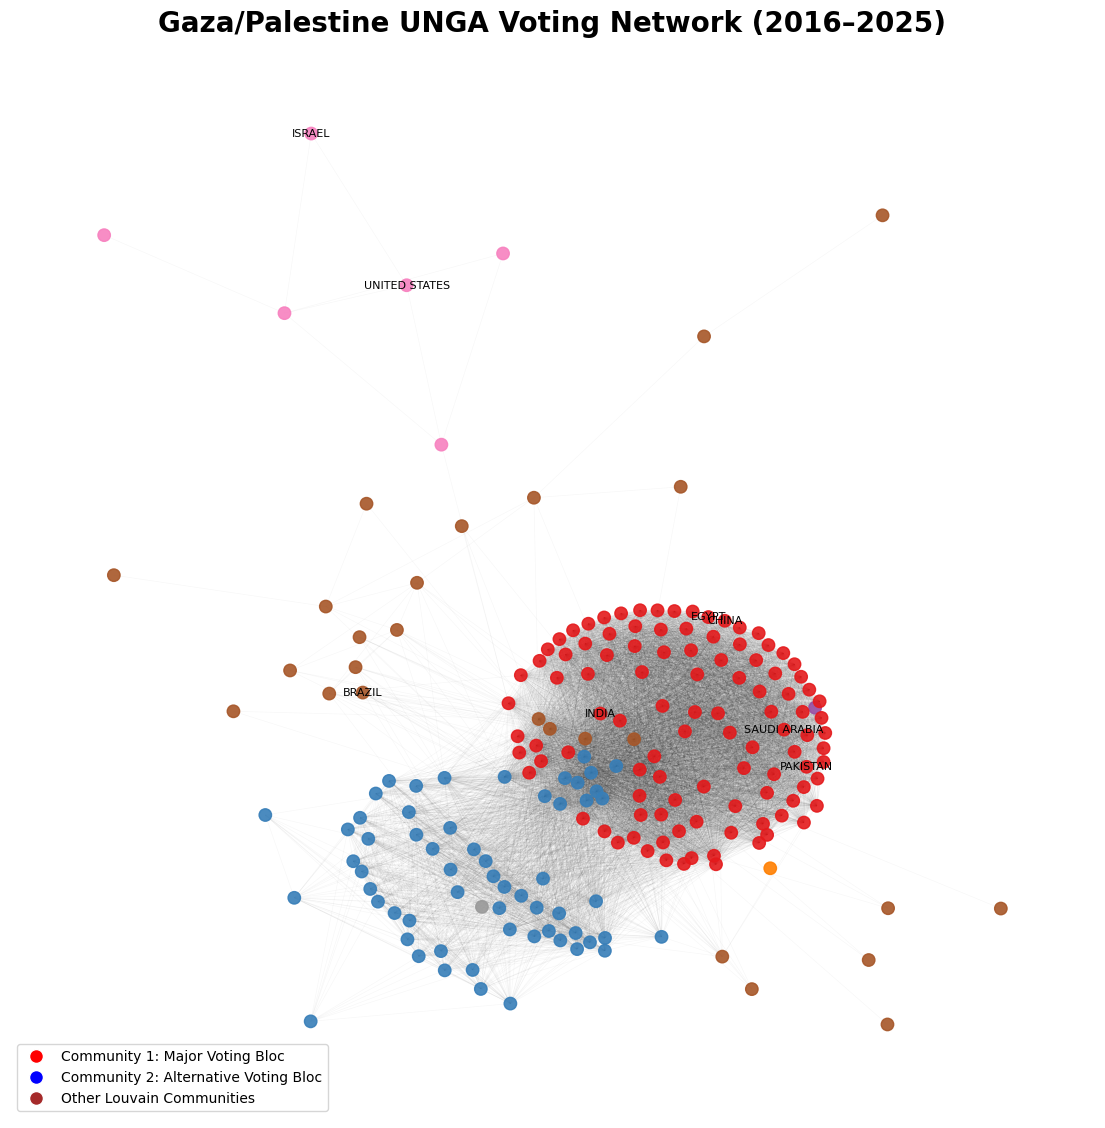

In [42]:
import matplotlib.pyplot as plt
import networkx as nx
from community import community_louvain
from matplotlib.lines import Line2D

# Detect communities
partition = community_louvain.best_partition(
    gaza_G,
    random_state=42
)

# Generate layout
pos = nx.kamada_kawai_layout(gaza_G)

# Community colors
colors = [partition[node] for node in gaza_G.nodes()]

plt.figure(figsize=(14,14))

# Draw nodes
nx.draw_networkx_nodes(
    gaza_G,
    pos,
    node_color=colors,
    cmap=plt.cm.Set1,
    node_size=80,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(
    gaza_G,
    pos,
    alpha=0.03,
    width=0.5
)

# Important countries
labels = {
    "UNITED STATES": "UNITED STATES",
    "ISRAEL": "ISRAEL",
    "CHINA": "CHINA",
    "SAUDI ARABIA": "SAUDI ARABIA",
    "PAKISTAN": "PAKISTAN",
    "EGYPT": "EGYPT",
    "BRAZIL": "BRAZIL",
    "INDIA": "INDIA"
}

# Draw labels
nx.draw_networkx_labels(
    gaza_G,
    pos,
    labels=labels,
    font_size=8
)

# Figure title
plt.title(
    "Gaza/Palestine UNGA Voting Network (2016–2025)",
    fontsize=20,
    fontweight="bold"
)

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Community 1: Major Voting Bloc',
        markerfacecolor='red',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Community 2: Alternative Voting Bloc',
        markerfacecolor='blue',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Other Louvain Communities',
        markerfacecolor='brown',
        markersize=10
    )
]

plt.legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=10
)

plt.axis("off")

plt.savefig(
    "Figure_8_2_Gaza_Network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

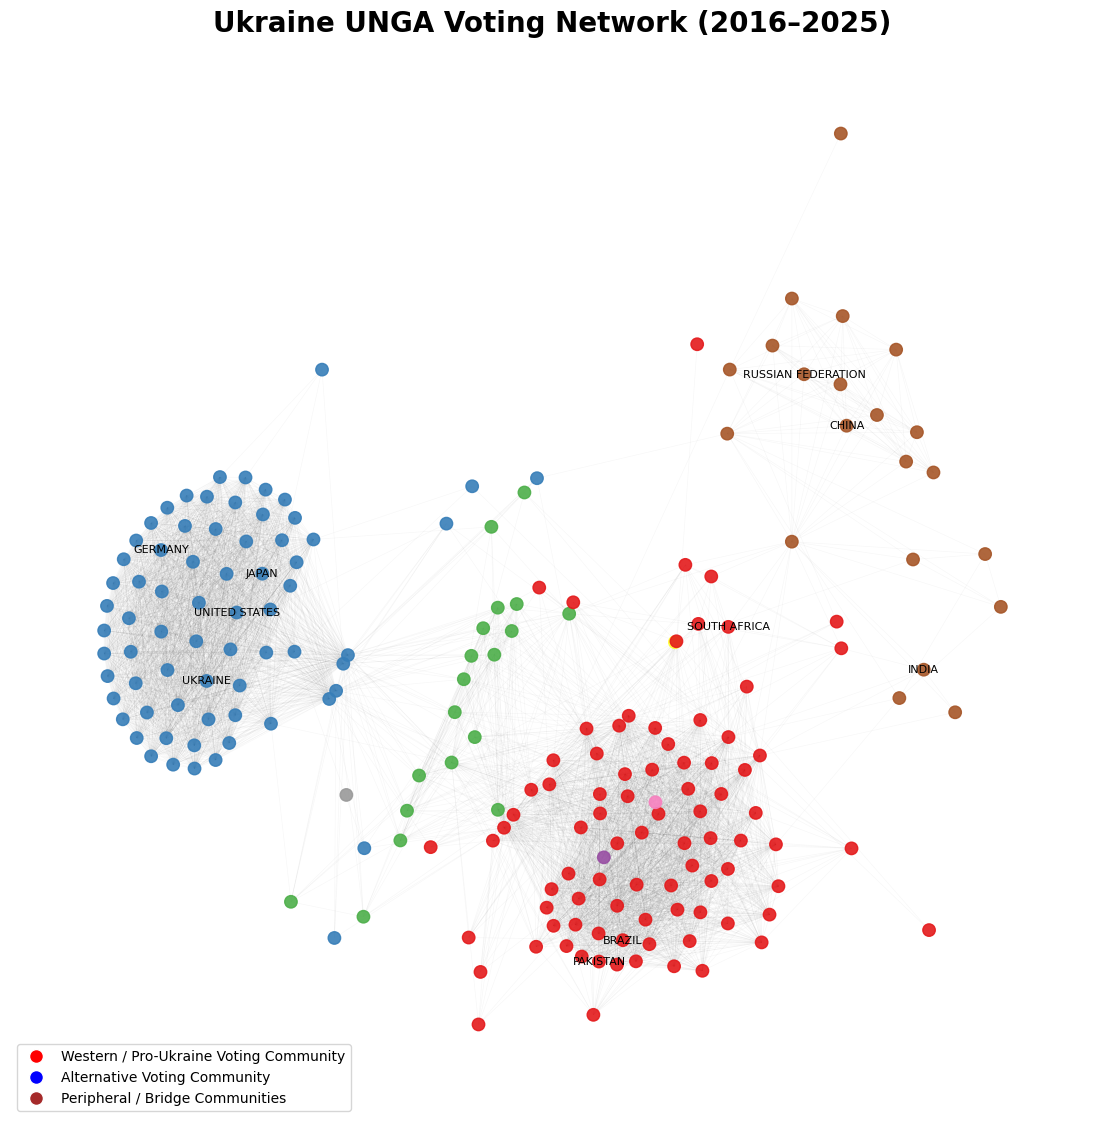

In [43]:
import matplotlib.pyplot as plt
import networkx as nx
from community import community_louvain
from matplotlib.lines import Line2D

# Detect communities
partition = community_louvain.best_partition(
    ukraine_G,
    random_state=42
)

# Generate layout
pos = nx.kamada_kawai_layout(ukraine_G)

# Community colors
colors = [partition[node] for node in ukraine_G.nodes()]

plt.figure(figsize=(14,14))

# Draw nodes
nx.draw_networkx_nodes(
    ukraine_G,
    pos,
    node_color=colors,
    cmap=plt.cm.Set1,
    node_size=80,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(
    ukraine_G,
    pos,
    alpha=0.03,
    width=0.5
)

# Important countries
labels = {
    "UNITED STATES": "UNITED STATES",
    "UKRAINE": "UKRAINE",
    "RUSSIAN FEDERATION": "RUSSIAN FEDERATION",
    "CHINA": "CHINA",
    "INDIA": "INDIA",
    "GERMANY": "GERMANY",
    "JAPAN": "JAPAN",
    "BRAZIL": "BRAZIL",
    "PAKISTAN": "PAKISTAN",
    "SOUTH AFRICA": "SOUTH AFRICA"
}

# Draw labels
nx.draw_networkx_labels(
    ukraine_G,
    pos,
    labels=labels,
    font_size=8
)

# Figure title
plt.title(
    "Ukraine UNGA Voting Network (2016–2025)",
    fontsize=20,
    fontweight="bold"
)

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Western / Pro-Ukraine Voting Community',
        markerfacecolor='red',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Alternative Voting Community',
        markerfacecolor='blue',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Peripheral / Bridge Communities',
        markerfacecolor='brown',
        markersize=10
    )
]

plt.legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=10
)

plt.axis("off")

plt.savefig(
    "Figure_8_3_Ukraine_Network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

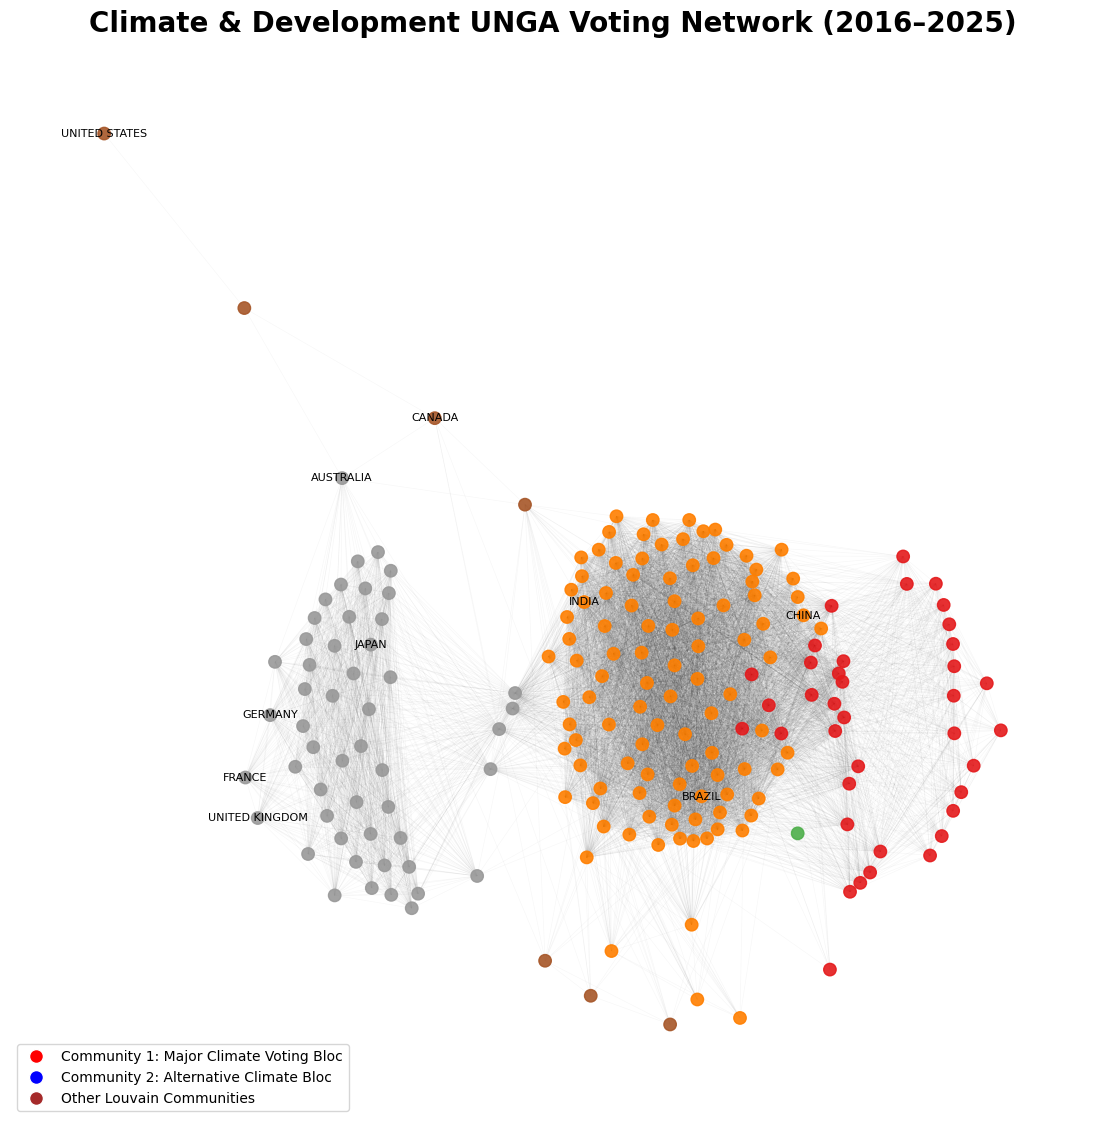

In [44]:
import matplotlib.pyplot as plt
import networkx as nx
from community import community_louvain
from matplotlib.lines import Line2D

# Detect communities
partition = community_louvain.best_partition(
    climate_G,
    random_state=42
)

# Generate layout
pos = nx.kamada_kawai_layout(climate_G)

# Community colors
colors = [partition[node] for node in climate_G.nodes()]

plt.figure(figsize=(14,14))

# Draw nodes
nx.draw_networkx_nodes(
    climate_G,
    pos,
    node_color=colors,
    cmap=plt.cm.Set1,
    node_size=80,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(
    climate_G,
    pos,
    alpha=0.03,
    width=0.5
)

# Important countries
labels = {
    "UNITED STATES": "UNITED STATES",
    "CHINA": "CHINA",
    "INDIA": "INDIA",
    "GERMANY": "GERMANY",
    "JAPAN": "JAPAN",
    "BRAZIL": "BRAZIL",
    "UNITED KINGDOM": "UNITED KINGDOM",
    "FRANCE": "FRANCE",
    "CANADA": "CANADA",
    "AUSTRALIA": "AUSTRALIA"
}

# Draw labels
nx.draw_networkx_labels(
    climate_G,
    pos,
    labels=labels,
    font_size=8
)

# Figure title
plt.title(
    "Climate & Development UNGA Voting Network (2016–2025)",
    fontsize=20,
    fontweight="bold"
)

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Community 1: Major Climate Voting Bloc',
        markerfacecolor='red',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Community 2: Alternative Climate Bloc',
        markerfacecolor='blue',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Other Louvain Communities',
        markerfacecolor='brown',
        markersize=10
    )
]

plt.legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=10
)

plt.axis("off")

plt.savefig(
    "Figure_8_4_Climate_Network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

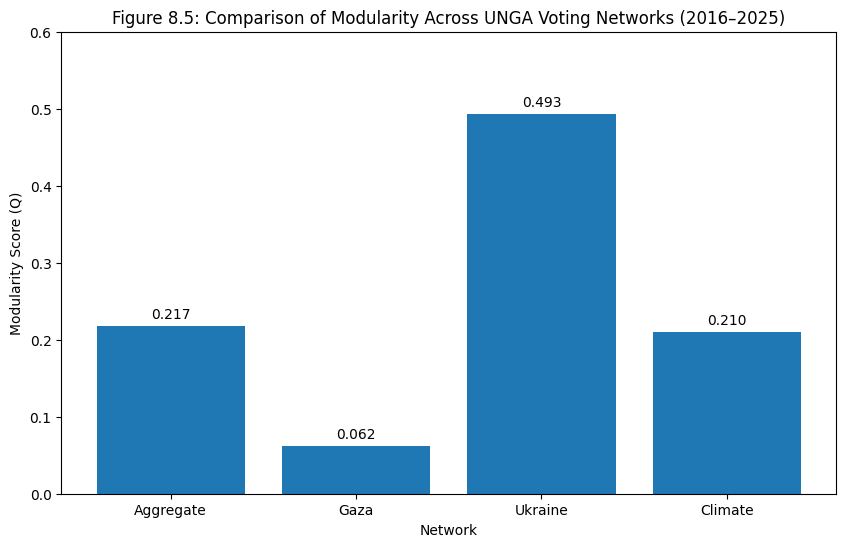

In [45]:
import matplotlib.pyplot as plt

# Replace these with your FINAL values from Python
networks = [
    "Aggregate",
    "Gaza",
    "Ukraine",
    "Climate"
]

modularity = [
    0.2175,   # Aggregate
    0.0624,   # Gaza
    0.4926,   # Ukraine
    0.2096    # Climate
]

plt.figure(figsize=(10,6))

plt.bar(
    networks,
    modularity
)

plt.xlabel("Network")
plt.ylabel("Modularity Score (Q)")
plt.title(
    "Figure 8.5: Comparison of Modularity Across UNGA Voting Networks (2016–2025)"
)

# Add values on top of bars
for i, value in enumerate(modularity):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha='center'
    )

plt.ylim(0, 0.6)

plt.savefig(
    "Figure_8_5_Modularity_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
df_2016_2025["ms_vote"].value_counts()

,count
ms_vote,
Y,121364
A,17464
X,14508
N,11293


In [47]:
from community import community_louvain
from collections import Counter

partition_aggregate = community_louvain.best_partition(aggregate_G, weight='weight', random_state=42)
partition_gaza = community_louvain.best_partition(gaza_G, weight='weight', random_state=42)
partition_ukraine = community_louvain.best_partition(ukraine_G, weight='weight', random_state=42)
partition_climate = community_louvain.best_partition(climate_G, weight='weight', random_state=42)

print("Aggregate:", Counter(partition_aggregate.values()))
print("Gaza:", Counter(partition_gaza.values()))
print("Ukraine:", Counter(partition_ukraine.values()))
print("Climate:", Counter(partition_climate.values()))

sample = ["United States","China","Russian Federation","United Kingdom","France","India","Germany","Japan","Brazil","Pakistan","South Africa","Indonesia","Saudi Arabia","Iran (Islamic Republic of)","Egypt","Nigeria","Mexico","Argentina","Canada","Australia","Italy","Republic of Korea","Turkey","Ukraine","Israel"]

for c in sample:
    # Convert country names to uppercase to match partition keys
    c_upper = c.upper()
    print(f"{c} Agg: {partition_aggregate.get(c_upper)} Gaza: {partition_gaza.get(c_upper)} Ukr: {partition_ukraine.get(c_upper)} Clim: {partition_climate.get(c_upper)}")

import networkx as nx
print("Modularity Agg:", community_louvain.modularity(partition_aggregate, aggregate_G, weight='weight'))
print("Modularity Gaza:", community_louvain.modularity(partition_gaza, gaza_G, weight='weight'))
print("Modularity Ukr:", community_louvain.modularity(partition_ukraine, ukraine_G, weight='weight'))
print("Modularity Clim:", community_louvain.modularity(partition_climate, climate_G, weight='weight'))

Aggregate: Counter({2: 139, 3: 56, 4: 2, 0: 1, 1: 1})
Gaza: Counter({0: 104, 1: 60, 4: 26, 5: 6, 2: 1, 6: 1, 3: 1})
Ukraine: Counter({0: 85, 1: 70, 5: 21, 2: 19, 4: 1, 7: 1, 3: 1, 6: 1})
Climate: Counter({2: 102, 4: 51, 0: 38, 3: 7, 1: 1})
United States Agg: 4 Gaza: 5 Ukr: 1 Clim: 3
China Agg: 2 Gaza: 0 Ukr: 5 Clim: 2
Russian Federation Agg: 1 Gaza: 1 Ukr: 5 Clim: 2
United Kingdom Agg: 3 Gaza: 1 Ukr: 1 Clim: 4
France Agg: 3 Gaza: 1 Ukr: 1 Clim: 4
India Agg: 2 Gaza: 0 Ukr: 5 Clim: 2
Germany Agg: 3 Gaza: 1 Ukr: 1 Clim: 4
Japan Agg: 3 Gaza: 1 Ukr: 1 Clim: 4
Brazil Agg: 2 Gaza: 4 Ukr: 0 Clim: 2
Pakistan Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
South Africa Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
Indonesia Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
Saudi Arabia Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
Iran (Islamic Republic of) Agg: 2 Gaza: 0 Ukr: 5 Clim: 0
Egypt Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
Nigeria Agg: 2 Gaza: 0 Ukr: 0 Clim: 2
Mexico Agg: 2 Gaza: 1 Ukr: 0 Clim: 2
Argentina Agg: 2 Gaza: 0 Ukr: 2 Clim: 2
Canada Agg: 3 Gaza: 5 Ukr: 1 

In [48]:
# check actual node name format
print(list(aggregate_G.nodes())[:10])

# case-insensitive lookup
def find_community(name, partition, graph):
    for node in graph.nodes():
        if node.strip().upper() == name.strip().upper():
            return partition.get(node)
    return None

sample = ["United States","China","Russian Federation","United Kingdom","France","India","Germany","Japan","Brazil","Pakistan","South Africa","Indonesia","Saudi Arabia","Iran","Egypt","Nigeria","Mexico","Argentina","Canada","Australia","Italy","Republic of Korea","Turkey","Ukraine","Israel"]

for c in sample:
    a = find_community(c, partition_aggregate, aggregate_G)
    g = find_community(c, partition_gaza, gaza_G)
    u = find_community(c, partition_ukraine, ukraine_G)
    cl = find_community(c, partition_climate, climate_G)
    print(c, "Agg:", a, "Gaza:", g, "Ukr:", u, "Clim:", cl)

['AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'ANDORRA', 'ANGOLA', 'ANTIGUA AND BARBUDA', 'ARGENTINA', 'ARMENIA', 'AUSTRALIA', 'AUSTRIA']
United States Agg: 4 Gaza: 5 Ukr: 1 Clim: 3
China Agg: 2 Gaza: 0 Ukr: 5 Clim: 2
Russian Federation Agg: 1 Gaza: 1 Ukr: 5 Clim: 2
United Kingdom Agg: 3 Gaza: 1 Ukr: 1 Clim: 4
France Agg: 3 Gaza: 1 Ukr: 1 Clim: 4
India Agg: 2 Gaza: 0 Ukr: 5 Clim: 2
Germany Agg: 3 Gaza: 1 Ukr: 1 Clim: 4
Japan Agg: 3 Gaza: 1 Ukr: 1 Clim: 4
Brazil Agg: 2 Gaza: 4 Ukr: 0 Clim: 2
Pakistan Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
South Africa Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
Indonesia Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
Saudi Arabia Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
Iran Agg: None Gaza: None Ukr: None Clim: None
Egypt Agg: 2 Gaza: 0 Ukr: 0 Clim: 0
Nigeria Agg: 2 Gaza: 0 Ukr: 0 Clim: 2
Mexico Agg: 2 Gaza: 1 Ukr: 0 Clim: 2
Argentina Agg: 2 Gaza: 0 Ukr: 2 Clim: 2
Canada Agg: 3 Gaza: 5 Ukr: 1 Clim: 3
Australia Agg: 3 Gaza: 2 Ukr: 1 Clim: 4
Italy Agg: 3 Gaza: 1 Ukr: 1 Clim: 4
Republic of Korea Agg: 3 Gaza: 1 Ukr

In [49]:
for i in range(3):
    p = community_louvain.best_partition(gaza_G, weight='weight', random_state=42)
    print(community_louvain.modularity(p, gaza_G, weight='weight'))

0.19216606050505458
0.19216606050505458
0.19216606050505458


In [50]:
for i in range(3):
    p = community_louvain.best_partition(gaza_G, weight='weight', random_state=42)
    print(community_louvain.modularity(p, gaza_G, weight='weight'))

0.19216606050505458
0.19216606050505458
0.19216606050505458


In [51]:
for i in range(3):
    p = community_louvain.best_partition(gaza_G, weight='weight', random_state=42)
    print(community_louvain.modularity(p, gaza_G, weight='weight'))

0.19216606050505458
0.19216606050505458
0.19216606050505458
